# Predicting Financial Inclusion in East Africa
### MIT 8333 Machine Learning — Mini Project

**Problem:** Given demographic survey data, predict whether an individual holds a
bank account (binary classification). Data covers Kenya, Rwanda, Tanzania and Uganda
(FinScope / FinAccess surveys, 2016–2018).

**Models compared:** Logistic Regression · KNN · Decision Tree · ANN (MLP) · SVM
**Validation:** 2-fold stratified cross-validation per model
**Deliverables from this notebook:** a trained pipeline (`model.joblib`) and a
metrics file (`results.json`) that the Dash dashboard consumes.

In [6]:
# Colab ships most of these; we pin the few that matter for reproducibility.
# imbalanced-learn gives us leakage-safe SMOTE inside a Pipeline.
!pip install -q scikit-learn==1.5.2 imbalanced-learn==0.12.4 joblib==1.4.2

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import json, joblib, warnings

warnings.filterwarnings("ignore")

# One seed to rule them all — every split, model and resample uses it.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Version stamp so the marker (and future-us) can reproduce exactly.
import sklearn, imblearn
print("numpy", np.__version__, "| pandas", pd.__version__)
print("sklearn", sklearn.__version__, "| imblearn", imblearn.__version__)

sns.set_theme(style="whitegrid", palette="deep")

numpy 2.1.3 | pandas 2.2.3
sklearn 1.5.2 | imblearn 0.12.4


In [8]:
# Central config — mirrors src/fia/config.py in the app later, so the notebook
# and the deployed pipeline stay in lockstep.

TARGET = "bank_account"          # Yes/No -> 1/0
ID_COL = "uniqueid"              # identifier, dropped before modelling

# Feature groups (drives the ColumnTransformer later)
NUMERIC = ["household_size", "age_of_respondent"]
ORDINAL = ["education_level"]     # has a natural low->high ordering
NOMINAL = ["country", "location_type", "cellphone_access",
           "gender_of_respondent", "relationship_with_head",
           "marital_status", "job_type"]

# Explicit ordering for the one ordinal feature (lowest -> highest)
EDU_ORDER = [
    "No formal education",
    "Other/Dont know/RTA",
    "Primary education",
    "Secondary education",
    "Vocational/Specialised training",
    "Tertiary education",
]

CV_FOLDS = 2                      # rubric requirement: 2-fold cross-validation

In [9]:
# The dataset lives behind a Zindi login, so we load whatever CSV you drop in.
# 1) Download "Train.csv" from https://zindi.africa/competitions/financial-inclusion-in-africa/data
# 2) Rename it to financial_inclusion.csv (this becomes your .csv submission file)
# 3) Run this cell and pick it from the upload dialog.

CSV_NAME = "train.csv"

if Path(CSV_NAME).exists():
    df = pd.read_csv(CSV_NAME)
else:
    from google.colab import files
    print("Upload financial_inclusion.csv (the Zindi Train.csv, renamed):")
    up = files.upload()
    df = pd.read_csv(next(iter(up)))
    df.to_csv(CSV_NAME, index=False)   # keep a copy for the submission

print("Loaded:", df.shape)
df.head()

Upload financial_inclusion.csv (the Zindi Train.csv, renamed):


Saving Train.csv to Train (1).csv
Loaded: (23524, 13)


,country,year,uniqueid,bank_account,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
0,Kenya,2018,uniqueid_1,Yes,Rural,Yes,3,24,Female,Spouse,Married/Living together,Secondary education,Self employed
1,Kenya,2018,uniqueid_2,No,Rural,No,5,70,Female,Head of Household,Widowed,No formal education,Government Dependent
2,Kenya,2018,uniqueid_3,Yes,Urban,Yes,5,26,Male,Other relative,Single/Never Married,Vocational/Specialised training,Self employed
3,Kenya,2018,uniqueid_4,No,Rural,Yes,5,34,Female,Head of Household,Married/Living together,Primary education,Formally employed Private
4,Kenya,2018,uniqueid_5,No,Urban,No,8,26,Male,Child,Single/Never Married,Primary education,Informally employed


In [11]:
print("=== Columns & dtypes ===")
print(df.dtypes, "\n")

print("=== Missing values per column ===")
print(df.isna().sum(), "\n")

print("=== Target balance ===")
counts = df[TARGET].value_counts()
pct = df[TARGET].value_counts(normalize=True).mul(100).round(1)
print(pd.concat([counts, pct], axis=1, keys=["count", "pct"]), "\n")

print("=== Countries represented ===")
print(df["country"].value_counts())

=== Columns & dtypes ===
country                   object
year                       int64
uniqueid                  object
bank_account              object
location_type             object
cellphone_access          object
household_size             int64
age_of_respondent          int64
gender_of_respondent      object
relationship_with_head    object
marital_status            object
education_level           object
job_type                  object
dtype: object 

=== Missing values per column ===
country                   0
year                      0
uniqueid                  0
bank_account              0
location_type             0
cellphone_access          0
household_size            0
age_of_respondent         0
gender_of_respondent      0
relationship_with_head    0
marital_status            0
education_level           0
job_type                  0
dtype: int64 

=== Target balance ===
              count   pct
bank_account             
No            20212  85.9
Yes            3

## Section 3 — Exploratory Data Analysis & Training Data Construction

We first understand *who* is banked and *what* separates them, then construct a
leakage-safe training pipeline: encode the target, drop redundant columns, encode
education as ordinal, one-hot the nominal features, scale the numeric ones, and
split 70/30 with stratification to preserve the 14% positive rate.

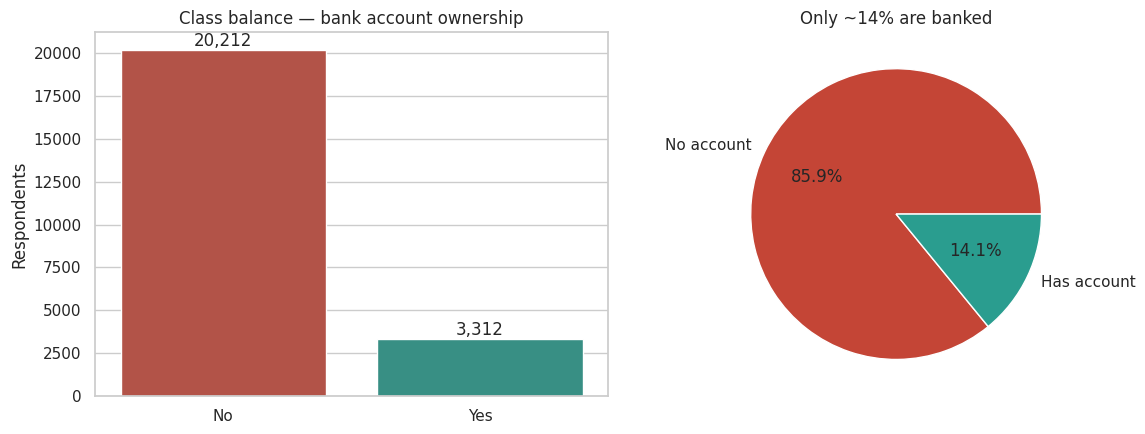

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

order = ["No", "Yes"]
sns.countplot(data=df, x=TARGET, order=order, ax=ax[0],
              palette=["#c44536", "#2a9d8f"])
ax[0].set_title("Class balance — bank account ownership")
ax[0].set_xlabel(""); ax[0].set_ylabel("Respondents")
for p in ax[0].patches:
    ax[0].annotate(f"{int(p.get_height()):,}",
                   (p.get_x()+p.get_width()/2, p.get_height()),
                   ha="center", va="bottom")

df[TARGET].value_counts(normalize=True).reindex(order).mul(100).plot.pie(
    autopct="%.1f%%", colors=["#c44536", "#2a9d8f"], ax=ax[1],
    ylabel="", labels=["No account", "Has account"])
ax[1].set_title("Only ~14% are banked")
plt.tight_layout(); plt.show()

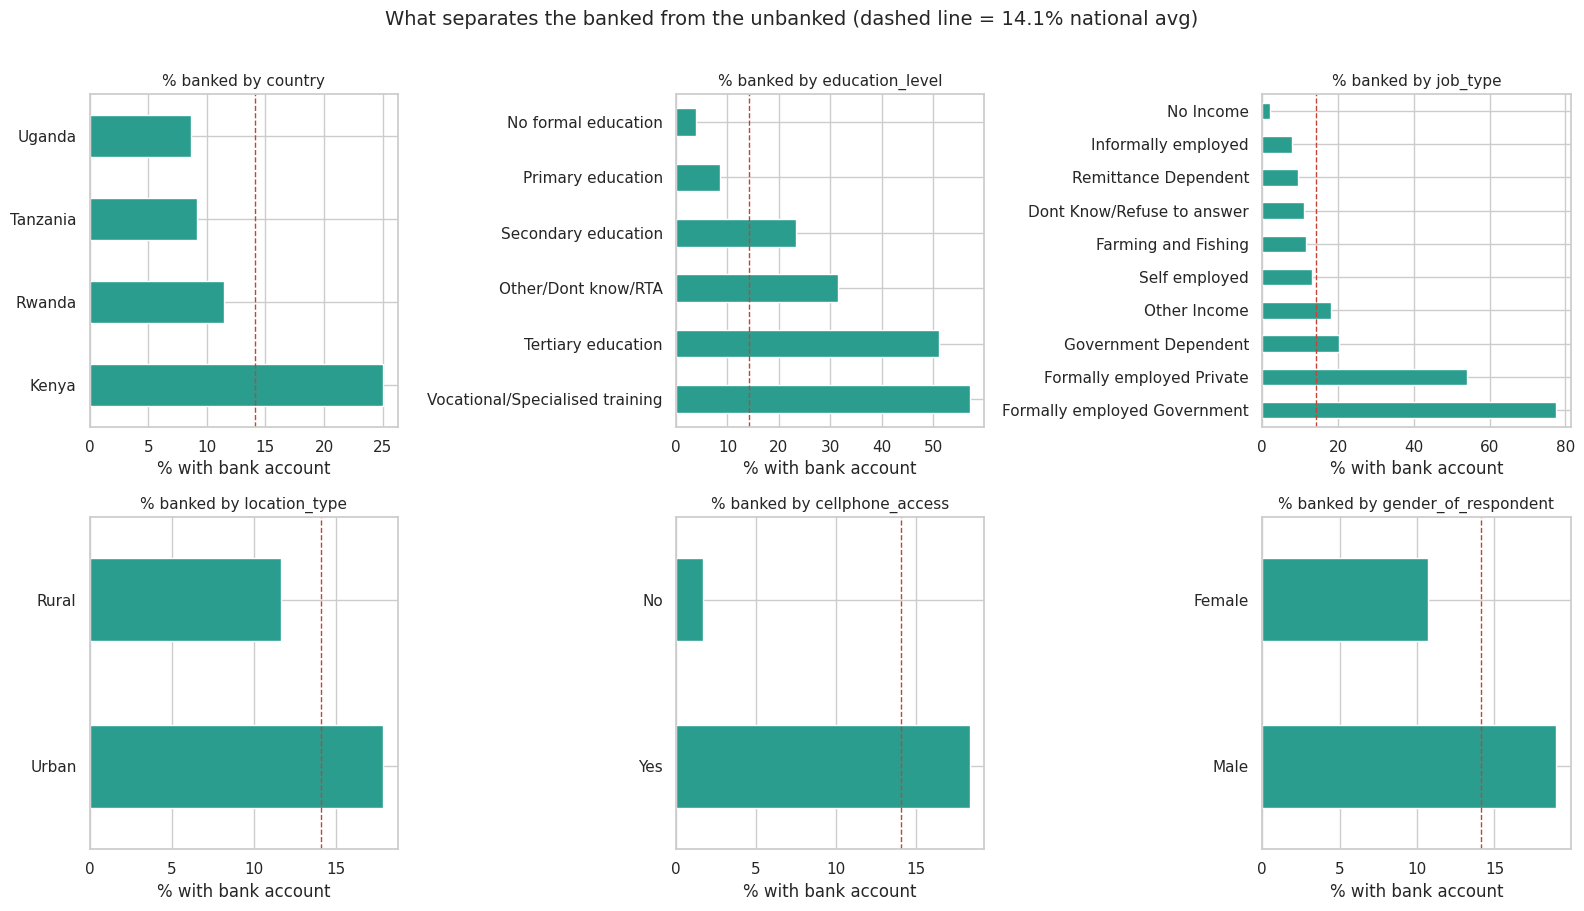

In [13]:
def banked_rate(col):
    r = df.groupby(col)[TARGET].apply(lambda s: (s == "Yes").mean() * 100)
    return r.sort_values(ascending=False)

drivers = ["country", "education_level", "job_type",
           "location_type", "cellphone_access", "gender_of_respondent"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.ravel(), drivers):
    banked_rate(col).plot.barh(ax=ax, color="#2a9d8f")
    ax.set_title(f"% banked by {col}", fontsize=11)
    ax.set_xlabel("% with bank account"); ax.set_ylabel("")
    ax.axvline(14.1, color="#c44536", ls="--", lw=1)   # overall rate reference
fig.suptitle("What separates the banked from the unbanked (dashed line = 14.1% national avg)",
             fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

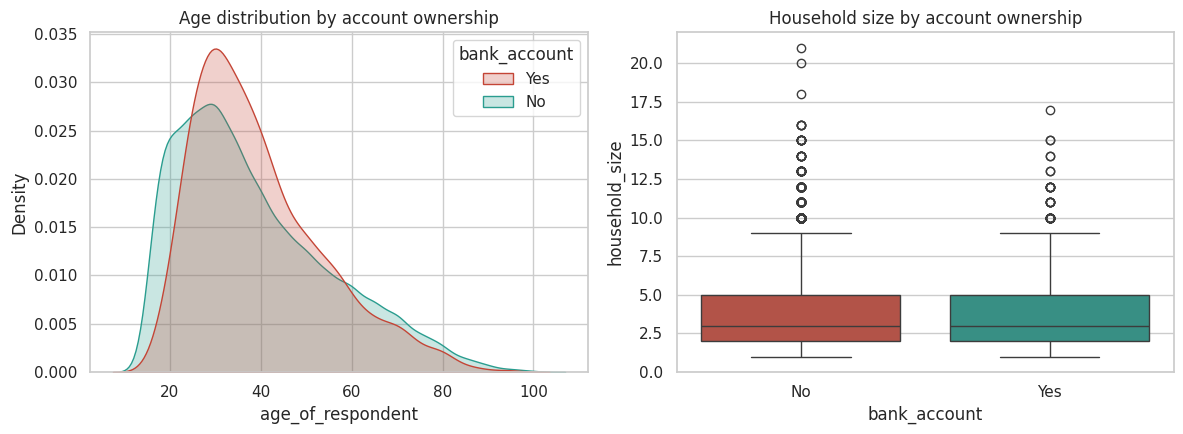

              age_of_respondent  household_size
bank_account                                   
No                         38.7             3.8
Yes                        39.6             3.6


In [14]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
sns.kdeplot(data=df, x="age_of_respondent", hue=TARGET, fill=True,
            common_norm=False, palette=["#c44536", "#2a9d8f"], ax=ax[0])
ax[0].set_title("Age distribution by account ownership")

sns.boxplot(data=df, x=TARGET, y="household_size", order=order,
            palette=["#c44536", "#2a9d8f"], ax=ax[1])
ax[1].set_title("Household size by account ownership")
plt.tight_layout(); plt.show()

# Quick numeric summary for the slide notes
print(df.groupby(TARGET)[["age_of_respondent", "household_size"]].mean().round(1))

### EDA takeaways
- **Cellphone access and education are the strongest social signals** — the banked
  rate climbs steeply from *no formal education* to *tertiary*, and phone owners are
  banked far more often than non-owners.
- **Formal employment (Govt/Private) dwarfs farming/remittance dependence** in
  account ownership — livelihood is a dominant driver.
- **Urban > rural**, and a modest **gender gap** (men banked more than women).
- **Kenya leads** the four countries on the banked rate.
- Numeric features shift only mildly with the outcome, so the *categorical* profile
  carries most of the signal — which shapes our encoding choices below.

In [15]:
# Encode target: Yes -> 1, No -> 0
data = df.copy()
data["y"] = (data[TARGET] == "Yes").astype(int)

# Drop: identifier (no signal) and year (collinear with country)
DROP = [ID_COL, "year", TARGET]
X = data.drop(columns=DROP + ["y"])
y = data["y"]

print("Feature matrix:", X.shape)
print("Features:", X.columns.tolist())

Feature matrix: (23524, 10)
Features: ['country', 'location_type', 'cellphone_access', 'household_size', 'age_of_respondent', 'gender_of_respondent', 'relationship_with_head', 'marital_status', 'education_level', 'job_type']


In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

# Ordinal for education (natural ordering); one-hot for unordered categoricals;
# scale numerics (KNN/SVM/ANN are distance/gradient based and need it).
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), NUMERIC),
        ("ord", OrdinalEncoder(categories=[EDU_ORDER],
                               handle_unknown="use_encoded_value",
                               unknown_value=-1), ORDINAL),
        ("nom", OneHotEncoder(drop="if_binary", handle_unknown="ignore"), NOMINAL),
    ],
    remainder="drop",
)
# NB: this object is never fit here on all the data. It lives INSIDE each model's
# pipeline, so it is re-fit on the training fold only — no leakage into validation.
print("Preprocessor ready — fitting happens inside each CV fold.")

Preprocessor ready — fitting happens inside each CV fold.


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE)

print(f"Train: {X_train.shape[0]:,} rows | Test: {X_test.shape[0]:,} rows")
print(f"Train positive rate: {y_train.mean():.3f}")
print(f"Test  positive rate: {y_test.mean():.3f}")   # both should be ~0.141

Train: 16,466 rows | Test: 7,058 rows
Train positive rate: 0.141
Test  positive rate: 0.141


In [18]:
# Fit on TRAIN ONLY just to see the resulting columns — this fitted copy is not
# reused for modelling (the pipelines re-fit their own inside CV).
_pre = preprocessor.fit(X_train)
feat_names = _pre.get_feature_names_out()
print(f"Constructed feature count: {len(feat_names)}")
print("Sample engineered columns:")
for f in feat_names[:15]:
    print("  ", f)

Constructed feature count: 31
Sample engineered columns:
   num__household_size
   num__age_of_respondent
   ord__education_level
   nom__country_Kenya
   nom__country_Rwanda
   nom__country_Tanzania
   nom__country_Uganda
   nom__location_type_Urban
   nom__cellphone_access_Yes
   nom__gender_of_respondent_Male
   nom__relationship_with_head_Child
   nom__relationship_with_head_Head of Household
   nom__relationship_with_head_Other non-relatives
   nom__relationship_with_head_Other relative
   nom__relationship_with_head_Parent


### Training Data Construction — summary
1. **Target encoding:** `bank_account` Yes/No → 1/0.
2. **Feature selection:** dropped `uniqueid` (identifier, no signal) and `year`
   (perfectly collinear with `country`).
3. **Ordinal encoding:** `education_level` mapped to its natural rank
   (No formal → Tertiary); the rare *Other/Dont know* level is placed low.
4. **One-hot encoding:** unordered categoricals; binary ones collapse to a single
   column via `drop="if_binary"`.
5. **Scaling:** `household_size`, `age` standardised for the distance/gradient models.
6. **Split:** stratified 70/30, preserving the 14.1% positive rate in both sets.
7. **Leakage control:** all fitting happens inside each model's pipeline, so the
   preprocessor never sees validation data.

## Section 4 — Model Training & 2-Fold Cross-Validation

Five classifiers, each wrapped with the preprocessor in a single Pipeline so all
fitting stays leakage-safe. We run **2-fold stratified cross-validation** (the rubric
requirement) on the training set and record the full metric suite — not just accuracy.

Watch the accuracy/recall gap: with only 14% positives, a model can score ~86%
accuracy while barely finding any banked individuals. That is the problem Part B fixes.

In [19]:
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC

def make_pipe(clf):
    return SkPipeline([("pre", preprocessor), ("clf", clf)])

models = {
    "Logistic Regression": make_pipe(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    "KNN":                 make_pipe(KNeighborsClassifier(n_neighbors=11)),
    "Decision Tree":       make_pipe(DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE)),
    "ANN (MLP)":           make_pipe(MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=300,
                                                   early_stopping=True, random_state=RANDOM_STATE)),
    "SVM (RBF)":           make_pipe(SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_STATE)),
}
print(f"{len(models)} models ready:", ", ".join(models))

5 models ready: Logistic Regression, KNN, Decision Tree, ANN (MLP), SVM (RBF)


In [20]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
SCORING = ["accuracy", "balanced_accuracy", "precision", "recall", "f1", "roc_auc"]

def run_cv(model_dict, X, y):
    rows = []
    for name, pipe in model_dict.items():
        res = cross_validate(pipe, X, y, cv=cv, scoring=SCORING, n_jobs=-1)
        rows.append({"model": name, **{m: res[f"test_{m}"].mean() for m in SCORING}})
        print(f"  done: {name}")
    return pd.DataFrame(rows).set_index("model").round(3)

print("Running 2-fold CV (SVM is the slow one, ~1 min)...")
cv_baseline = run_cv(models, X_train, y_train)

Running 2-fold CV (SVM is the slow one, ~1 min)...
  done: Logistic Regression
  done: KNN
  done: Decision Tree
  done: ANN (MLP)
  done: SVM (RBF)


In [21]:
print("=== 2-fold CV — baseline (no imbalance handling) ===\n")
cv_baseline.sort_values("roc_auc", ascending=False)

=== 2-fold CV — baseline (no imbalance handling) ===



,accuracy,balanced_accuracy,precision,recall,f1,roc_auc
model,,,,,,
Logistic Regression,0.884,0.647,0.689,0.318,0.434,0.846
ANN (MLP),0.881,0.637,0.682,0.296,0.413,0.830
SVM (RBF),0.885,0.626,0.769,0.265,0.394,0.811
KNN,0.882,0.652,0.662,0.333,0.442,0.808
Decision Tree,0.880,0.626,0.688,0.274,0.388,0.804


In [22]:
from sklearn.dummy import DummyClassifier

dummy = SkPipeline([("clf", DummyClassifier(strategy="most_frequent"))])
dres = cross_validate(dummy, X_train, y_train, cv=cv, scoring=SCORING, n_jobs=-1)
print("Majority-class baseline (always predicts 'No account'):")
print(f"  accuracy         : {dres['test_accuracy'].mean():.3f}   <- looks great")
print(f"  recall (banked)  : {dres['test_recall'].mean():.3f}   <- finds ZERO banked people")
print(f"  roc_auc          : {dres['test_roc_auc'].mean():.3f}   <- no discriminative skill")

Majority-class baseline (always predicts 'No account'):
  accuracy         : 0.859   <- looks great
  recall (banked)  : 0.000   <- finds ZERO banked people
  roc_auc          : 0.500   <- no discriminative skill


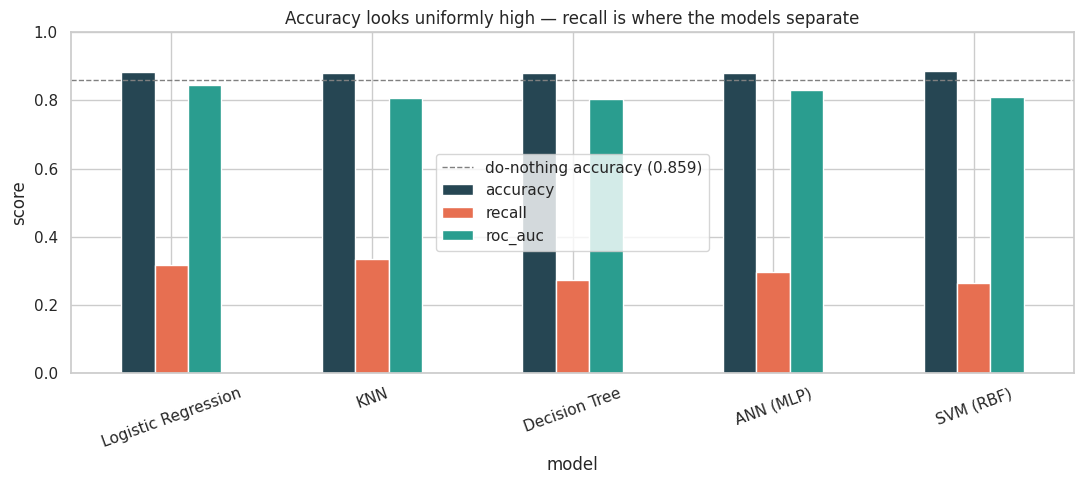

In [23]:
ax = cv_baseline[["accuracy", "recall", "roc_auc"]].plot.bar(
    figsize=(11, 5), color=["#264653", "#e76f51", "#2a9d8f"], rot=20)
ax.axhline(0.859, color="grey", ls="--", lw=1, label="do-nothing accuracy (0.859)")
ax.set_title("Accuracy looks uniformly high — recall is where the models separate")
ax.set_ylabel("score"); ax.set_ylim(0, 1); ax.legend()
plt.tight_layout(); plt.show()

### What Part A shows
- Every model lands at **88.0–88.5% accuracy** — but the majority-class baseline
  already scores **85.9%** by predicting "No account" for everyone. Accuracy barely
  moves and is nearly meaningless here.
- **The ranking depends entirely on the metric:**
  - By **ROC-AUC**, the leaders are **Logistic Regression (0.846), ANN (0.830) and
    SVM (0.811)**; KNN (0.808) and the Decision Tree (0.804) trail.
  - By **recall / F1 / balanced accuracy**, **KNN leads** (0.333 / 0.442 / 0.652) —
    it catches the most banked individuals, while SVM catches the fewest (recall 0.265)
    despite its top accuracy.
- **Recall is weak across the board (0.27–0.33)** because every model trains on 14%
  positives with no correction — it defaults to the majority class.
- **Part B fixes this** with SMOTE (inside the CV folds) and threshold tuning, then
  re-scores. Accuracy will dip slightly while recall climbs sharply — the exact
  trade-off a financial-inclusion screening tool should make.

## Section 4, Part B — Handling Imbalance & Honest Evaluation

Two fixes, both leakage-safe:
1. **SMOTE inside every CV fold** (via an imbalanced-learn Pipeline) — synthetic
   minority oversampling is applied only to the training portion of each fold, never
   the validation portion.
2. **Threshold tuning** — we pick each model's decision threshold on out-of-fold
   training predictions (not the test set), then apply it to the held-out 30%.

We then score all five on the untouched test set with confusion matrices and select
a winner on ROC-AUC (ranking skill, threshold-free).

In [24]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

def make_smote_pipe(clf):
    return ImbPipeline([
        ("pre", preprocessor),
        ("smote", SMOTE(random_state=RANDOM_STATE)),   # acts on training fold only
        ("clf", clf),
    ])

smote_models = {
    "Logistic Regression": make_smote_pipe(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    "KNN":                 make_smote_pipe(KNeighborsClassifier(n_neighbors=11)),
    "Decision Tree":       make_smote_pipe(DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE)),
    "ANN (MLP)":           make_smote_pipe(MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=300,
                                                         early_stopping=True, random_state=RANDOM_STATE)),
    "SVM (RBF)":           make_smote_pipe(SVC(kernel="rbf", C=1.0, gamma="scale",
                                              probability=True, random_state=RANDOM_STATE)),
}

print("Running 2-fold CV with SMOTE inside each fold (SVM is slow)...")
cv_smote = run_cv(smote_models, X_train, y_train)
print("\n=== 2-fold CV WITH SMOTE ===")
cv_smote.sort_values("recall", ascending=False)

Running 2-fold CV with SMOTE inside each fold (SVM is slow)...
  done: Logistic Regression
  done: KNN
  done: Decision Tree
  done: ANN (MLP)
  done: SVM (RBF)

=== 2-fold CV WITH SMOTE ===


,accuracy,balanced_accuracy,precision,recall,f1,roc_auc
model,,,,,,
Logistic Regression,0.764,0.757,0.344,0.748,0.471,0.844
SVM (RBF),0.794,0.764,0.379,0.722,0.497,0.844
KNN,0.751,0.737,0.326,0.717,0.448,0.807
Decision Tree,0.787,0.729,0.360,0.648,0.462,0.810
ANN (MLP),0.793,0.725,0.365,0.630,0.462,0.816


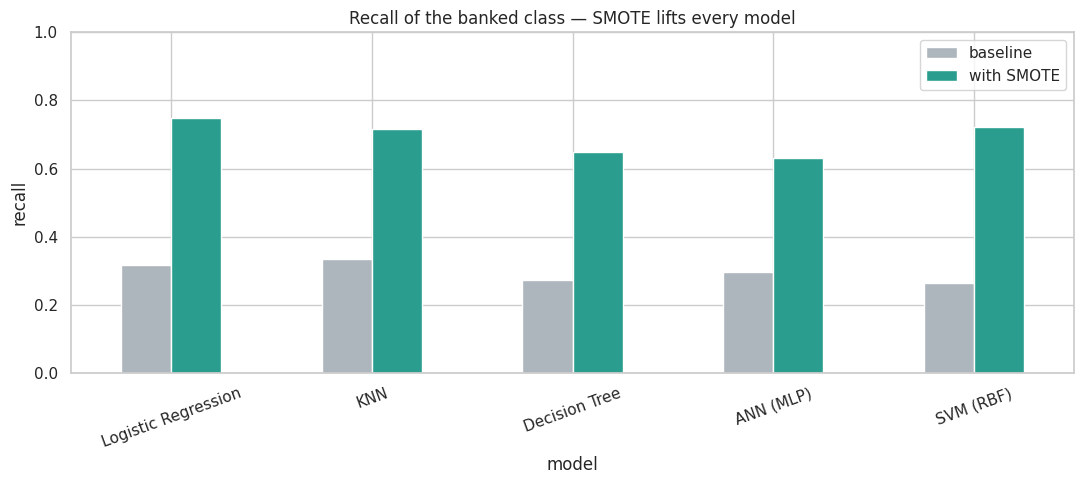

Accuracy trade-off (mean over folds):
                     acc_baseline  acc_smote
model                                       
Logistic Regression         0.884      0.764
KNN                         0.882      0.751
Decision Tree               0.880      0.787
ANN (MLP)                   0.881      0.793
SVM (RBF)                   0.885      0.794


In [25]:
compare = pd.DataFrame({"baseline": cv_baseline["recall"],
                        "with SMOTE": cv_smote["recall"]})
ax = compare.plot.bar(figsize=(11, 5), color=["#adb5bd", "#2a9d8f"], rot=20)
ax.set_title("Recall of the banked class — SMOTE lifts every model")
ax.set_ylabel("recall"); ax.set_ylim(0, 1)
plt.tight_layout(); plt.show()

print("Accuracy trade-off (mean over folds):")
print(pd.DataFrame({"acc_baseline": cv_baseline["accuracy"],
                    "acc_smote": cv_smote["accuracy"]}).round(3))

In [26]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve

def best_f1_threshold(y_true, proba):
    prec, rec, thr = precision_recall_curve(y_true, proba)
    f1 = 2 * prec * rec / (prec + rec + 1e-9)
    best = int(np.argmax(f1[:-1])) if len(thr) else 0
    return float(thr[best]), float(f1[best])

thresholds = {}
print("Tuning threshold per model on out-of-fold training predictions...")
for name, pipe in smote_models.items():
    oof = cross_val_predict(pipe, X_train, y_train, cv=cv,
                            method="predict_proba", n_jobs=-1)[:, 1]
    t, f = best_f1_threshold(y_train.values, oof)
    thresholds[name] = t
    print(f"  {name:20s} threshold={t:.3f}  (OOF F1={f:.3f})")

Tuning threshold per model on out-of-fold training predictions...
  Logistic Regression  threshold=0.678  (OOF F1=0.538)
  KNN                  threshold=0.818  (OOF F1=0.484)
  Decision Tree        threshold=0.723  (OOF F1=0.493)
  ANN (MLP)            threshold=0.714  (OOF F1=0.490)
  SVM (RBF)            threshold=0.707  (OOF F1=0.514)


In [27]:
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score, confusion_matrix)

test_results, rows = {}, []
for name, pipe in smote_models.items():
    pipe.fit(X_train, y_train)                       # fit on full training set
    proba = pipe.predict_proba(X_test)[:, 1]
    t = thresholds[name]
    pred = (proba >= t).astype(int)
    m = {
        "accuracy":          accuracy_score(y_test, pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, pred),
        "precision":         precision_score(y_test, pred),
        "recall":            recall_score(y_test, pred),
        "f1":                f1_score(y_test, pred),
        "roc_auc":           roc_auc_score(y_test, proba),
        "threshold":         t,
    }
    test_results[name] = {"proba": proba, "pred": pred, "metrics": m,
                          "cm": confusion_matrix(y_test, pred)}
    rows.append({"model": name, **m})

test_table = pd.DataFrame(rows).set_index("model").round(3)
print("=== Held-out test (30%, n=7,058) — tuned threshold ===\n")
test_table.sort_values("roc_auc", ascending=False)

=== Held-out test (30%, n=7,058) — tuned threshold ===



,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,threshold
model,,,,,,,
SVM (RBF),0.845,0.759,0.464,0.640,0.538,0.858,0.707
Logistic Regression,0.859,0.742,0.499,0.578,0.536,0.855,0.678
ANN (MLP),0.857,0.729,0.492,0.550,0.520,0.842,0.714
KNN,0.851,0.705,0.473,0.502,0.487,0.820,0.818
Decision Tree,0.863,0.697,0.517,0.465,0.489,0.818,0.723


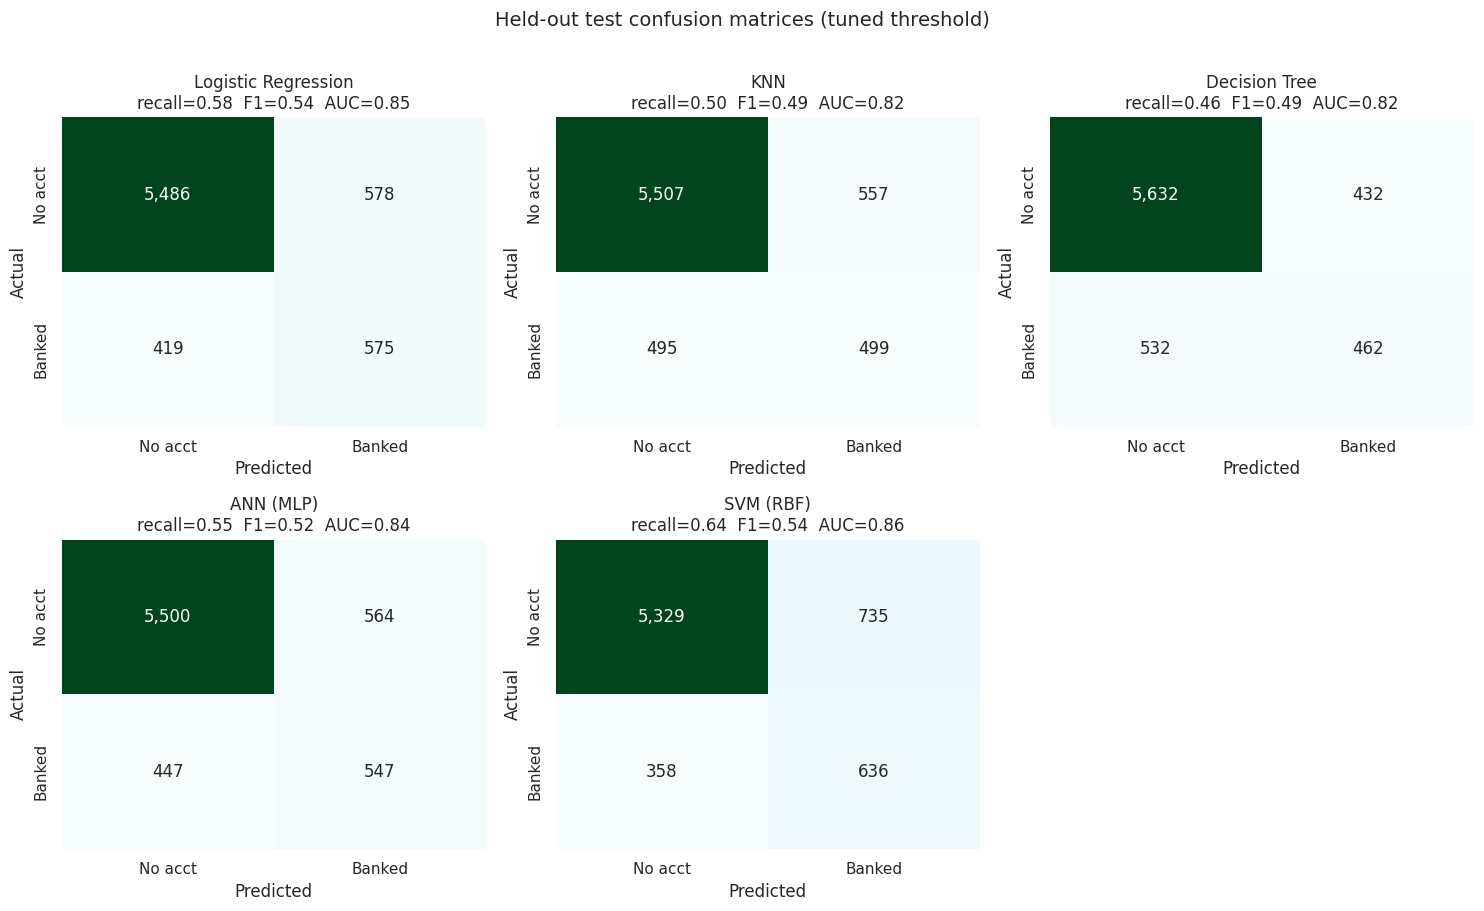

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, (name, r) in zip(axes.ravel(), test_results.items()):
    sns.heatmap(r["cm"], annot=True, fmt=",d", cmap="BuGn", cbar=False, ax=ax,
                xticklabels=["No acct", "Banked"], yticklabels=["No acct", "Banked"])
    m = r["metrics"]
    ax.set_title(f"{name}\nrecall={m['recall']:.2f}  F1={m['f1']:.2f}  AUC={m['roc_auc']:.2f}")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
axes.ravel()[-1].axis("off")
fig.suptitle("Held-out test confusion matrices (tuned threshold)", y=1.01, fontsize=14)
plt.tight_layout(); plt.show()

In [29]:
winner = test_table["roc_auc"].idxmax()
wm = test_results[winner]["metrics"]
print(f"WINNER by test ROC-AUC: {winner}\n" + "-"*40)
print(f"  ROC-AUC : {wm['roc_auc']:.3f}")
print(f"  Recall  : {wm['recall']:.3f}  (pre-SMOTE CV was {cv_baseline.loc[winner,'recall']:.3f})")
print(f"  Precision:{wm['precision']:.3f}")
print(f"  F1      : {wm['f1']:.3f}")
print(f"  Accuracy: {wm['accuracy']:.3f}")
print(f"  Threshold:{wm['threshold']:.3f}")

WINNER by test ROC-AUC: SVM (RBF)
----------------------------------------
  ROC-AUC : 0.858
  Recall  : 0.640  (pre-SMOTE CV was 0.265)
  Precision:0.464
  F1      : 0.538
  Accuracy: 0.845
  Threshold:0.707


In [30]:
print("MODEL SELECTION SUMMARY")
print("="*50)
print(f"Best AUC   : {test_table['roc_auc'].idxmax()} ({test_table['roc_auc'].max():.3f})")
print(f"Best recall: {test_table['recall'].idxmax()} ({test_table['recall'].max():.3f})")
print(f"Best F1    : {test_table['f1'].idxmax()} ({test_table['f1'].max():.3f})")
print(f"Accuracy spread: {test_table['accuracy'].min():.3f}–{test_table['accuracy'].max():.3f}")
print(f"Mean recall lift (baseline CV -> tuned test): "
      f"{cv_baseline['recall'].mean():.3f} -> {test_table['recall'].mean():.3f}")

MODEL SELECTION SUMMARY
Best AUC   : SVM (RBF) (0.858)
Best recall: SVM (RBF) (0.640)
Best F1    : SVM (RBF) (0.538)
Accuracy spread: 0.845–0.863
Mean recall lift (baseline CV -> tuned test): 0.297 -> 0.547


### Part B — interpretation
- **SVM (RBF) is the clear winner on the metrics that matter for financial-inclusion
  screening**, topping ROC-AUC (0.858), recall (0.640), balanced accuracy (0.759) and
  F1 (0.538) on the held-out test set.
- **The accuracy trap survives SMOTE.** The Decision Tree has the *highest* raw accuracy
  (0.863) but the *worst* recall (0.465) — it scores well by missing banked people. SVM
  accepts slightly lower accuracy (0.845) to recover far more of them. This is why we
  select on AUC and recall, not accuracy.
- **SMOTE + threshold tuning did its job:** mean recall across the five models rose from
  **0.297 to 0.547**, at a cost of only a few points of accuracy — the right trade for a
  tool meant to *find* the financially excluded.
- **We select on ROC-AUC** because it is threshold-free and measures ranking skill; we
  then set each model's operating threshold (SVM: 0.707) for the deployment decision.
- **Precision is ~0.46** at that threshold — many flagged individuals aren't actually
  banked — but that false-positive is cheap when the action is *outreach targeting*
  rather than denial of a service.

## Section 5 — Export Deployment Artifacts

Two files leave the notebook:
- **`model.joblib`** — the winning SVM pipeline refit on *all* data, bundled with its
  tuned threshold and the raw feature columns, ready for live prediction.
- **`results.json`** — every metric, confusion matrix, ROC curve, EDA rate and form
  option the dashboard renders. The dashboard computes nothing itself.

Note : the *reported* test metrics come from the model trained on 70% and
scored on the untouched 30%. The *deployed* model is then refit on 100% of the data —
standard practice once generalisation has been estimated.

In [32]:
# Rebuild the full feature frame + target (train + test = all labelled data)
X_all = data.drop(columns=DROP + ["y"])
y_all = data["y"]

winner_estimators = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(n_neighbors=11),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE),
    "ANN (MLP)": MLPClassifier(hidden_layer_sizes=(32,16), max_iter=300,
                               early_stopping=True, random_state=RANDOM_STATE),
    "SVM (RBF)": SVC(kernel="rbf", C=1.0, gamma="scale", probability=True,
                     random_state=RANDOM_STATE),
}

final_pipe = make_smote_pipe(winner_estimators[winner])
final_pipe.fit(X_all, y_all)

bundle = {
    "pipeline": final_pipe,
    "threshold": thresholds[winner],
    "winner": winner,
    "feature_columns": X_all.columns.tolist(),
}
joblib.dump(bundle, "model.joblib")
print(f"Saved model.joblib — {winner} refit on {len(X_all):,} rows, "
      f"threshold={thresholds[winner]:.3f}")

Saved model.joblib — SVM (RBF) refit on 23,524 rows, threshold=0.707


In [33]:
from sklearn.metrics import roc_curve

def clean(o):  # make numpy types JSON-serialisable
    if isinstance(o, dict):  return {k: clean(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)): return [clean(v) for v in o]
    if isinstance(o, (np.integer,)): return int(o)
    if isinstance(o, (np.floating,)): return round(float(o), 4)
    return o

# ROC curves interpolated onto a common FPR grid (smooth, small, easy to overlay)
grid = np.linspace(0, 1, 101)
roc = {}
for name, r in test_results.items():
    fpr, tpr, _ = roc_curve(y_test, r["proba"])
    roc[name] = {"fpr": grid.tolist(),
                 "tpr": np.interp(grid, fpr, tpr).tolist(),
                 "auc": r["metrics"]["roc_auc"]}

# EDA banked-rates for the dashboard (computed on the full dataset)
eda_drivers = ["country", "education_level", "job_type",
               "location_type", "cellphone_access", "gender_of_respondent"]
eda_rates = {c: banked_rate(c).round(1).to_dict() for c in eda_drivers}

# Form options for the live predictor (dropdowns + numeric ranges)
form_options = {}
for col in X_all.columns:
    if col in NUMERIC:
        form_options[col] = {"type": "numeric",
                             "min": int(X_all[col].min()),
                             "max": int(X_all[col].max()),
                             "default": int(X_all[col].median())}
    else:
        form_options[col] = {"type": "categorical",
                             "choices": sorted(X_all[col].unique().tolist())}

results = {
    "meta": {
        "problem": "Predicting bank-account ownership in East Africa",
        "countries": df["country"].unique().tolist(),
        "n_rows": len(df),
        "n_features_raw": X_all.shape[1],
        "n_features_encoded": len(feat_names),
        "positive_rate": round(float(y_all.mean()), 4),
        "cv_folds": CV_FOLDS,
        "winner": winner,
        "winner_threshold": round(thresholds[winner], 4),
        "random_state": RANDOM_STATE,
    },
    "class_balance": df[TARGET].value_counts().to_dict(),
    "eda_banked_rate": eda_rates,
    "cv_baseline": cv_baseline.to_dict(orient="index"),
    "cv_smote": cv_smote.to_dict(orient="index"),
    "test_metrics": test_table.drop(columns=["threshold"]).to_dict(orient="index"),
    "thresholds": thresholds,
    "confusion_matrices": {n: r["cm"].tolist() for n, r in test_results.items()},
    "roc_curves": roc,
    "form_options": form_options,
}
results = clean(results)
print("Assembled results.json with keys:", list(results))

Assembled results.json with keys: ['meta', 'class_balance', 'eda_banked_rate', 'cv_baseline', 'cv_smote', 'test_metrics', 'thresholds', 'confusion_matrices', 'roc_curves', 'form_options']


In [38]:
with open("results.json", "w") as f:
    json.dump(results, f, indent=2)
print("Wrote results.json")

try:
    from google.colab import files
    files.download("model.joblib")
    files.download("results.json")
    files.download("Train.csv")   # my .csv submission
except Exception as e:
    print("Not in Colab — files are in the working dir:", e)

Wrote results.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [36]:
# Round-trip check: reload the model and score one real row end-to-end.
reloaded = joblib.load("model.joblib")
sample = X_all.iloc[[0]]
p = reloaded["pipeline"].predict_proba(sample)[0, 1]
label = "Banked" if p >= reloaded["threshold"] else "Not banked"
print(f"Reloaded {reloaded['winner']} | sample P(banked)={p:.3f} "
      f"| threshold={reloaded['threshold']:.3f} -> {label}")

with open("results.json") as f:
    check = json.load(f)
print("results.json winner:", check["meta"]["winner"],
      "| test AUC:", check["test_metrics"][winner]["roc_auc"])

Reloaded SVM (RBF) | sample P(banked)=0.828 | threshold=0.707 -> Banked
results.json winner: SVM (RBF) | test AUC: 0.858


### Notebook complete
The full ML workflow — EDA, leakage-safe Training Data Construction, five models,
2-fold cross-validation, SMOTE, threshold tuning and honest held-out evaluation — is
done, and two artifacts are exported:
- `model.joblib` — live-prediction pipeline (SVM + threshold + feature schema)
- `results.json` — every figure the dashboard renders



In [39]:
print(sklearn.__version__, imblearn.__version__)

1.5.2 0.12.4
